### Necessary Imports

In [ ]:
from astropy.table import Table
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib
import polars as pl

#### Now we'll use the stored rcparams.txt file to format our figure

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

### Now let's read in all our good CNN predicted periods

In [3]:
reportable = pd.read_csv('reportable.csv', index_col='Unnamed: 0').rename(columns={'edr3_source_id':'EDR3'})
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']
reportable['abs_g_mag'] = reportable['phot_g_mean_mag'] - 5*np.log10(1000/reportable['parallax']) + 5
reportable['frac'] = reportable['sigma']/reportable['period']

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### And divide them into their subpopulations

In [4]:
cold = reportable[reportable['bp-rp'] >= 0.6]
hot = reportable[reportable['bp-rp'] < 0.6]

oscillators = cold[cold['abs_g_mag'] <= ((2*cold['bp-rp']) - 4)]
nonoscillators = cold[cold['abs_g_mag'] > ((2*cold['bp-rp']) - 4)]

subgiants = nonoscillators[nonoscillators['abs_g_mag'] < ((1.4*nonoscillators['bp-rp'])+2.8)]
ms = nonoscillators[nonoscillators['abs_g_mag'] >= ((1.4*nonoscillators['bp-rp'])+2.8)]

### Read in the Gaia information now for all ASAS-SN stars and plot

In [5]:
gaiaids = pl.read_parquet('allgaiadata.parq').to_pandas()
gaia_kept = gaiaids['phot_g_mean_mag']
del gaiaids

In [6]:
reported_giants = oscillators['phot_g_mean_mag']
reported_dwarfs = ms['phot_g_mean_mag']

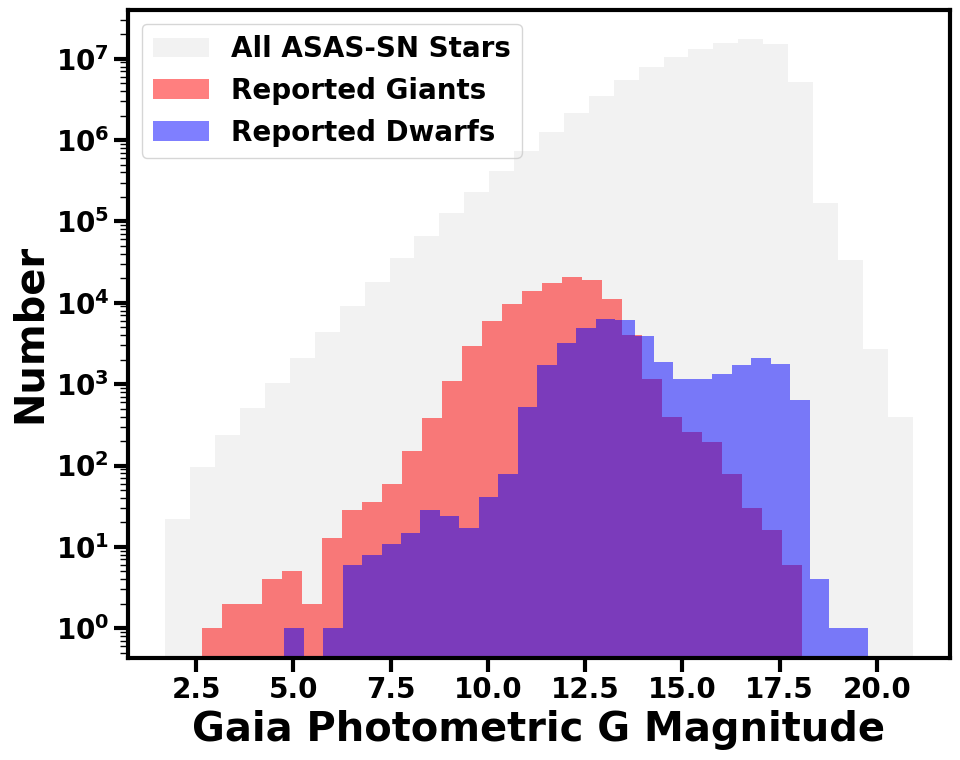

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(10, 8), tight_layout=True)

axs.hist(gaia_kept, bins=30, color='black', label='All ASAS-SN Stars', alpha=0.05)
axs.hist(reported_giants, bins=30, color='red', label='Reported Giants',alpha=0.5)
axs.hist(reported_dwarfs, bins=30, color='blue', label='Reported Dwarfs', alpha=0.5)
axs.set(yscale='log', ylabel='Number', xlabel='Gaia Photometric G Magnitude')
fig.set_facecolor('white')
plt.legend()
plt.show()